<a href="https://colab.research.google.com/github/auliatauhid/Data-Science-2026/blob/main/Pertemuan7_AuliaTauhid_250401020136.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aulia Tauhid Akbar - 250401020136 - Data Science IF405**

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


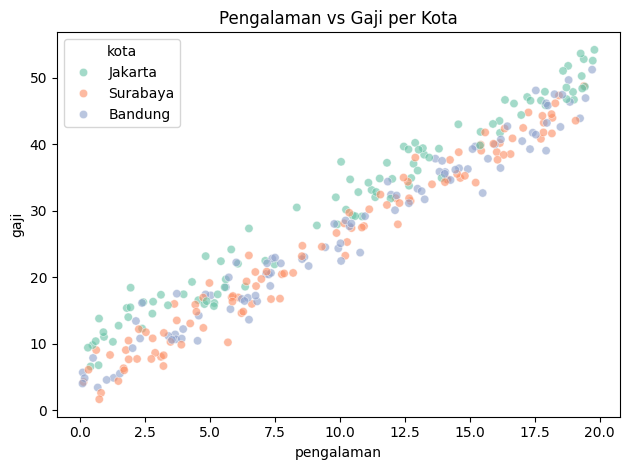

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Konfigurasi ──────────────────────────────────────────────────────────────
np.random.seed(42)
N = 300

# ── Generate dataset sintetis ─────────────────────────────────────────────────
pengalaman = np.random.uniform(0, 20, N)
edu        = np.random.choice([0, 1, 2], N)          # 0=SMA, 1=D3, 2=S1
kota       = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], N)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, N)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu':        edu,
    'kota':       kota,
    'gaji':       gaji,
})

# ── EDA singkat ───────────────────────────────────────────────────────────────
print('Shape:', df.shape)
print(df.describe().round(2))

# ── Visualisasi: Pengalaman vs Gaji per Kota ──────────────────────────────────
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6,
)
plt.title('Pengalaman vs Gaji per Kota')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── One-Hot Encoding kolom 'kota' ─────────────────────────────────────────────
df = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# ── Pisahkan fitur dan target ─────────────────────────────────────────────────
X = df.drop('gaji', axis=1)
y = df['gaji']

# ── Train-Test Split ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# ── Scaling — fit pada training set saja, transform keduanya ─────────────────
scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train)
X_test_s    = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()

coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif → gaji naik
# Koefisien negatif → gaji turun

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test_s)

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE              = {mae:.3f} juta rupiah')
print(f'RMSE             = {rmse:.3f} juta rupiah')
print(f'R²               = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse - mae:.3f}')

# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R² cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?

=== Metrik Evaluasi ===
MAE              = 1.649 juta rupiah
RMSE             = 2.123 juta rupiah
R²               = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


## Interpretasi Metrik Evaluasi Model

### 1. Rata-rata Kesalahan Prediksi
- **MAE = 1.649 juta rupiah** → rata-rata prediksi model meleset sekitar **Rp 1.649.000** dari gaji aktual.
- **RMSE = 2.123 juta rupiah** → kesalahan rata-rata dengan penalti lebih besar untuk error ekstrem.

### 2. Apakah R² Cukup Baik?
- **R² = 0.9740 (97.4%)** → model mampu menjelaskan **97.4% variasi gaji**, yang tergolong **sangat baik**.
- Untuk kasus prediksi gaji, R² di atas 0.90 sudah dianggap excellent.

### 3. Indikasi Outlier
- **Selisih RMSE − MAE = 0.474** → selisih ini relatif kecil, artinya **tidak ada outlier ekstrem** yang signifikan.
- Jika selisihnya besar (misal > 2×MAE), itu mengindikasikan adanya outlier yang menarik RMSE jauh di atas MAE.

### ✅ Kesimpulan
Model regresi linear bekerja dengan sangat baik pada dataset ini.
Kesalahan prediksi rata-rata hanya ~Rp 1.6 juta dengan R² 97.4%,
dan tidak ada indikasi outlier yang mengkhawatirkan.

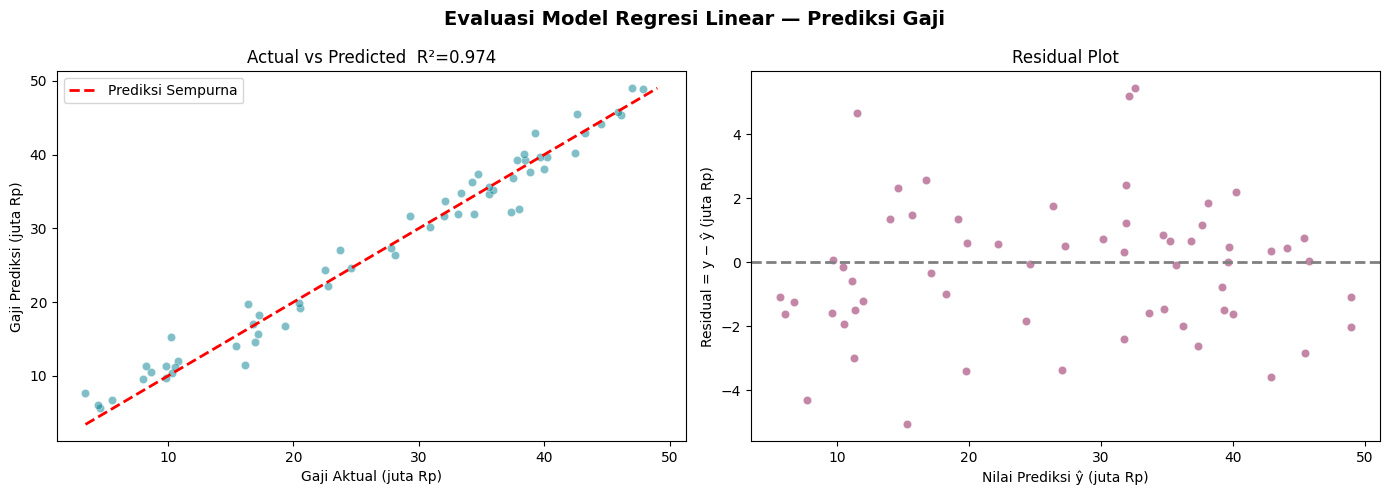

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Actual vs Predicted ────────────────────────────────────────────
axes[0].scatter(
    y_test, y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  R²={r2:.3f}')
axes[0].legend()

# ── Plot 2: Residual Plot ──────────────────────────────────────────────────
residuals = y_test - y_pred

axes[1].scatter(
    y_pred, residuals,
    alpha=0.5,
    color='#880E4F',
    edgecolors='white',
    lw=0.5
)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle(
    'Evaluasi Model Regresi Linear — Prediksi Gaji',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

# Cara membaca Residual Plot:
# ✅ Baik    : titik tersebar ACAK di sekitar garis y=0
# ❌ Masalah : ada pola (kurva, corong) → asumsi linearitas dilanggar

**Kesimpulan**

Apa yang Dipelajari

Program ini membangun model regresi linear end-to-end pada dataset sintetis prediksi gaji — dari generate data, EDA, encoding, scaling, training LinearRegression, evaluasi dengan MAE/RMSE/R², hingga visualisasi Actual vs Predicted dan Residual Plot.

Temuan Utama

Model bekerja sangat baik — wajar karena datanya sintetis:
MetrikNilaiMAE1.649 juta RpRMSE2.123 juta RpR²0.9740 (97.4%)
R² setinggi ini masuk akal karena data di-generate dengan persamaan linear yang eksplisit — model pada dasarnya "menemukan kembali" rumus yang sudah diketahui.
Koefisien model sesuai dengan ground truth yang ditanam:

pengalaman (koef 13.04) → faktor paling dominan, sesuai parameter asli 2.2 × std pengalaman
kota_Jakarta (koef 1.84) → bonus kota Jakarta tertangkap dengan baik
edu (koef 1.19) → pengaruh pendidikan terdeteksi
kota_Surabaya (koef -0.29) → referensi Bandung, Surabaya sedikit lebih rendah — konsisten

Selisih RMSE − MAE = 0.474 (kecil) → tidak ada outlier ekstrem yang mengganggu model.

Keterbatasan / Pertanyaan yang Muncul

R² 97.4% bisa menyesatkan sebagai benchmark — angka ini tinggi bukan karena model canggih, tapi karena data memang dibuat linear dengan noise kecil (std=2). Di data nyata, R² 0.6–0.7 sudah cukup bagus untuk prediksi gaji.
Ada bug subtle pada encoding — output kolom setelah get_dummies menunjukkan 'gaji' ikut masuk dalam list kolom fitur sebelum dipisah ke y. Urutan operasi benar (X dibuat setelah encoding), tapi tampilan print-nya bisa membingungkan.
edu diperlakukan sebagai numerik kontinu — padahal 0/1/2 adalah ordinal (SMA < D3 < S1). Ini kebetulan tidak masalah di sini karena urutannya memang linear, tapi di kasus lain bisa misleading jika jarak antar level tidak sama.
Residual Plot tidak dianalisis secara kuantitatif — apakah residual benar-benar berdistribusi normal? Perlu uji Shapiro-Wilk atau Q-Q plot untuk memvalidasi asumsi OLS.
Langkah natural berikutnya: uji model pada data nyata (misalnya dataset gaji Kaggle), tambah fitur interaksi (pengalaman × edu), dan bandingkan dengan Ridge/Lasso Regression untuk melihat apakah regularisasi diperlukan.